# Regime-Aware Adaptive Design of Experiments

A standalone prototype that composes three capabilities into an adaptive experimental loop:

1. **Regime Detection** — Detect when the process has shifted using rolling diagnostics + changepoint detection (PELT)
2. **Stable Feature Identification** — Find features that matter globally across regimes via noise-referenced bootstrap stability selection
3. **Adaptive DoE** — Fit a local surrogate on current-regime data, score candidate experiments, pick the best

**Dependencies:** `numpy`, `pandas`, `catboost`, `ruptures`, `scikit-learn`, `scipy`, `matplotlib`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
import ruptures
from catboost import CatBoostRegressor, Pool
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)
print("Imports OK")

Imports OK


## 1. Load Data

The example dataset has 150 historical runs with:
- 3 decision variables (`d_decision_0/1/2`) — controllable, range [-1, 1]
- 3 strong linear features, 2 moderate, 2 nonlinear, 3 proxy cluster, 7 noise
- 1 continuous context (`c_ambient_temp`) + 2 categorical
- Target: `t_yield`

**Toggle `DATA_FILE` below** to switch between datasets:
- `observed_data.csv` — 3 regimes, changepoints at run 50 and 100
- `observed_data_hard_mode.csv` — 5 regimes, changepoints every 30 runs, more aggressive coefficient shifts

In [2]:
# ── Toggle dataset here ──────────────────────────────────────────
DATA_FILE = "observed_data_hard_mode.csv"    # "observed_data.csv" or "observed_data_hard_mode.csv"
# ─────────────────────────────────────────────────────────────────

observed_df = pd.read_csv(DATA_FILE)
print(f"Dataset: {DATA_FILE}")
print(f"Shape: {observed_df.shape}")
print(f"Columns: {list(observed_df.columns)}")
print(f"\nTrue regime distribution:\n{observed_df['true_regime'].value_counts().sort_index()}")
print(f"\nMissing cells: {observed_df.isnull().sum().sum()} ({100*observed_df.isnull().sum().sum()/(observed_df.shape[0]*observed_df.shape[1]):.1f}%)")
print(f"\nt_yield range: {observed_df['t_yield'].min():.1f} to {observed_df['t_yield'].max():.1f}")

# ── Derive regime schedule and true changepoints from the data ───
# Build schedule: list of (first_run_in_regime, regime_id)
_regime_col = observed_df.sort_values("run_order")["true_regime"].values
REGIME_SCHEDULE = [(0, int(_regime_col[0]))]
for i in range(1, len(_regime_col)):
    if _regime_col[i] != _regime_col[i - 1]:
        REGIME_SCHEDULE.append((i, int(_regime_col[i])))

# True changepoints (run indices where regime changes)
TRUE_CHANGEPOINTS = [run for run, _ in REGIME_SCHEDULE[1:]]

print(f"\nDerived regime schedule: {REGIME_SCHEDULE}")
print(f"True changepoints: {TRUE_CHANGEPOINTS}")
print(f"Number of regimes: {len(REGIME_SCHEDULE)}")

Dataset: observed_data_hard_mode.csv
Shape: (150, 28)
Columns: ['run_id', 'run_order', 'true_regime', 'd_decision_0', 'd_decision_1', 'd_decision_2', 'c_ambient_temp', 'c_context_cat_0', 'c_context_cat_1', 'f_strong_linear_0', 'f_strong_linear_1', 'f_strong_linear_2', 'f_moderate_linear_0', 'f_moderate_linear_1', 'f_nonlinear_0', 'f_nonlinear_1', 'f_proxy_0', 'f_proxy_1', 'f_proxy_2', 'f_noise_0', 'f_noise_1', 'f_noise_2', 'f_noise_3', 'f_noise_4', 'f_noise_5', 'f_noise_6', 't_yield', 't_quality']

True regime distribution:
true_regime
0    30
1    30
2    30
3    30
4    30
Name: count, dtype: int64

Missing cells: 126 (3.0%)

t_yield range: -17.1 to 18.3

Derived regime schedule: [(0, 0), (30, 1), (60, 2), (90, 3), (120, 4)]
True changepoints: [30, 60, 90, 120]
Number of regimes: 5


## 2. Helper Functions

Everything the prototype needs, inlined. No external package dependencies beyond the standard scientific stack.

### 2a. Data Completion (Simple Median Imputation)

In [3]:
def complete_data(df: pd.DataFrame) -> pd.DataFrame:
    """Fill missing values: median for numeric, mode for categorical."""
    completed = df.copy()
    for col in completed.select_dtypes(include=[np.number]).columns:
        if completed[col].isna().any():
            completed[col] = completed[col].fillna(completed[col].median())
    for col in completed.select_dtypes(exclude=[np.number]).columns:
        if completed[col].isna().any():
            mode_vals = completed[col].mode()
            completed[col] = completed[col].fillna(
                mode_vals.iloc[0] if len(mode_vals) > 0 else "missing")
    return completed

### 2b. Regime Detection

Two-step approach:
1. Compute rolling diagnostic features (RMSE, R², importance entropy, residual stats) on a sliding window
2. Run PELT changepoint detection on the diagnostic signal to find regime boundaries

**Tuned parameters** (from systematic grid search over 1,008 configs × 10 seeds on hard mode data):
- **Window size**: 20
- **PELT cost model**: L2 (detects mean-shifts; dramatically outperforms RBF)
- **Channels**: all 6 (`rolling_rmse`, `rolling_r2`, `importance_entropy`, `residual_mean`, `residual_std`, `top_feature_jaccard`)
- **Penalty**: 8.0
- **min_size**: window_size (prevents micro-segments shorter than the diagnostic window)

In [4]:
def compute_rolling_diagnostics(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = "t_yield",
    window_size: int = 20,
) -> pd.DataFrame:
    """Compute rolling diagnostic features that shift at regime boundaries.
    
    Each row summarises the RF fit on a backward-looking window of
    `window_size` runs.  The `run_center` column records the centre of
    each window in run-order space (used for plotting).
    
    All six diagnostics are computed; the tuned configuration uses all
    six channels for PELT.
    """
    n = len(df)
    X = df[feature_cols].values.astype(float)
    y = df[target_col].values.astype(float)
    
    # Fill any NaN in X with column medians
    for j in range(X.shape[1]):
        mask = np.isnan(X[:, j])
        if mask.any():
            X[mask, j] = np.nanmedian(X[:, j])
    
    records = []
    prev_top5 = set()
    
    for i in range(window_size, n):
        idx = slice(i - window_size, i)
        X_w, y_w = X[idx], y[idx]
        
        # Fit small RF on the window
        rf = RandomForestRegressor(n_estimators=30, max_depth=4, random_state=42)
        rf.fit(X_w, y_w)
        preds = rf.predict(X_w)
        residuals = y_w - preds
        
        # RMSE
        rmse = np.sqrt(np.mean(residuals ** 2))
        
        # R²
        ss_res = np.sum(residuals ** 2)
        ss_tot = np.sum((y_w - y_w.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
        
        # Feature importance entropy
        imp = rf.feature_importances_
        imp = imp[imp > 0]
        entropy = -np.sum(imp * np.log(imp + 1e-12))
        
        # Top-5 feature Jaccard similarity
        top5 = set(np.argsort(rf.feature_importances_)[-5:])
        jaccard = len(top5 & prev_top5) / len(top5 | prev_top5) if prev_top5 else 1.0
        prev_top5 = top5
        
        records.append({
            "run_center": i - window_size // 2,   # centre of window in run-space
            "rolling_rmse": rmse,
            "rolling_r2": r2,
            "importance_entropy": entropy,
            "residual_mean": residuals.mean(),
            "residual_std": residuals.std(),
            "top_feature_jaccard": jaccard,
        })
    
    return pd.DataFrame(records)


def detect_regimes(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = "t_yield",
    window_size: int = 20,
    penalty: float = 8.0,
) -> tuple[np.ndarray, pd.DataFrame]:
    """Detect regimes via rolling diagnostics + PELT changepoint detection.
    
    Uses tuned configuration from grid search experiment (hard mode data):
    - L2 cost model (detects mean-shifts in diagnostic signal)
    - All 6 channels
    - Penalty 8.0
    - min_size = window_size to prevent micro-segments
    
    Returns
    -------
    labels : np.ndarray
        Integer regime label per row in df.
    diagnostics : pd.DataFrame
        Rolling diagnostic features (useful for plotting).
    """
    diag = compute_rolling_diagnostics(df, feature_cols, target_col, window_size)
    
    # Use all 6 diagnostic channels for PELT
    pelt_channels = [
        "rolling_rmse", "rolling_r2", "importance_entropy",
        "residual_mean", "residual_std", "top_feature_jaccard",
    ]
    signal = diag[pelt_channels].values.astype(float)
    signal = (signal - signal.mean(axis=0)) / (signal.std(axis=0) + 1e-12)
    
    # Run PELT with L2 cost model — min_size = window_size prevents
    # micro-segments shorter than the diagnostic window itself.
    algo = ruptures.Pelt(model="l2", min_size=window_size).fit(signal)
    breakpoints = algo.predict(pen=penalty)       # includes len(signal) as sentinel
    breakpoints = [bp for bp in breakpoints if bp < len(signal)]  # remove sentinel
    
    # Map diagnostic-space breakpoints → run-space boundaries.
    # Each diagnostic point d summarises the window [d, d+W).  The data
    # change that caused the diagnostic shift happened *inside* this window,
    # so the centre (d + W//2) is the best point estimate.
    n = len(df)
    labels = np.zeros(n, dtype=int)
    boundaries = sorted([bp + window_size // 2 for bp in breakpoints])
    for seg_id, bp in enumerate(boundaries, start=1):
        if bp < n:
            labels[bp:] = seg_id
    
    return labels, diag

# ── Feature-column helpers ─────────────────────────────────────────────────

def get_detection_feature_cols(df):
    """Numeric-only features for RF-based regime detection."""
    return [c for c in df.columns
            if (c.startswith(("f_", "d_")) and df[c].dtype.kind in ("f", "i"))
            or c == "c_ambient_temp"]


def get_surrogate_feature_cols(df, feature_set="expanded"):
    """Feature columns for surrogate modeling.

    'expanded' includes numeric d_/f_, c_ambient_temp, AND categorical context.
    'original' includes only numeric d_/f_ columns.
    """
    if feature_set == "expanded":
        numeric = [c for c in df.columns
                   if (c.startswith(("f_", "d_")) and df[c].dtype.kind in ("f", "i"))
                   or c == "c_ambient_temp"]
        categorical = [c for c in df.columns if c.startswith("c_context_cat")]
        return numeric + categorical
    else:
        return [c for c in df.columns
                if c.startswith(("f_", "d_")) and df[c].dtype.kind in ("f", "i")]


def get_cat_feature_indices(feature_cols, df):
    """Return list of positional indices for categorical columns (for CatBoost cat_features)."""
    indices = [i for i, c in enumerate(feature_cols) if df[c].dtype.kind not in ("f", "i")]
    return indices if indices else None


print("Regime detection functions defined (tuned: L2 model, all 6 channels, window=20, penalty=8.0).")
print("Feature-column helpers defined: get_detection_feature_cols, get_surrogate_feature_cols, get_cat_feature_indices.")

Regime detection functions defined (tuned: L2 model, all 6 channels, window=20, penalty=8.0).
Feature-column helpers defined: get_detection_feature_cols, get_surrogate_feature_cols, get_cat_feature_indices.


### 2c. Noise-Referenced Stability Selection

Bootstrap the data B times. Each time, fit CatBoost and record feature importances.
Also fit on shuffled targets to get a null distribution. Features whose real importance
exceeds the 95th percentile of the null in >50% of bootstraps are "stable."

In [5]:
def stability_selection(
    X: pd.DataFrame,
    y: np.ndarray,
    regime_labels: np.ndarray | None = None,
    n_bootstraps: int = 30,
    threshold: float = 0.5,
    seed: int = 42,
) -> tuple[list[str], pd.DataFrame]:
    """Noise-referenced bootstrap stability selection.
    
    Returns (selected_features, stability_df).
    """
    rng = np.random.default_rng(seed)
    features = list(X.columns)
    n = len(X)
    
    real_importances = np.zeros((n_bootstraps, len(features)))
    null_importances = np.zeros((n_bootstraps, len(features)))
    
    for b in range(n_bootstraps):
        # Stratified bootstrap (by regime if available)
        if regime_labels is not None:
            idx = []
            for lbl in np.unique(regime_labels):
                lbl_idx = np.where(regime_labels == lbl)[0]
                sampled = rng.choice(lbl_idx, size=len(lbl_idx), replace=True)
                idx.extend(sampled.tolist())
            idx = np.array(idx)
        else:
            idx = rng.choice(n, size=n, replace=True)
        
        X_b = X.iloc[idx].reset_index(drop=True)
        y_b = y[idx]
        
        # Real importance
        cb = CatBoostRegressor(
            depth=4, iterations=50, learning_rate=0.05,
            random_seed=seed + b, verbose=0, allow_writing_files=False,
        )
        _cat_idx = [i for i, c in enumerate(X_b.columns) if X_b[c].dtype.kind not in ("f", "i")]
        cb.fit(X_b, y_b, cat_features=_cat_idx if _cat_idx else None)
        imp = cb.get_feature_importance()
        total = imp.sum()
        real_importances[b] = imp / total if total > 0 else imp
        
        # Null importance (shuffled target)
        y_shuffled = rng.permutation(y_b)
        cb_null = CatBoostRegressor(
            depth=4, iterations=50, learning_rate=0.05,
            random_seed=seed + b + 10000, verbose=0, allow_writing_files=False,
        )
        cb_null.fit(X_b, y_shuffled, cat_features=_cat_idx if _cat_idx else None)
        imp_null = cb_null.get_feature_importance()
        total_null = imp_null.sum()
        null_importances[b] = imp_null / total_null if total_null > 0 else imp_null
    
    # Noise floor: 95th percentile of all null importances
    noise_floor = np.percentile(null_importances, 95)
    
    # Per-feature: fraction of bootstraps where real > noise_floor
    freq_sig = (real_importances > noise_floor).mean(axis=0)
    mean_imp = real_importances.mean(axis=0)
    
    stability_df = pd.DataFrame({
        "feature": features,
        "mean_importance": mean_imp,
        "freq_significant": freq_sig,
    }).set_index("feature").sort_values("mean_importance", ascending=False)
    
    selected = stability_df[stability_df["freq_significant"] >= threshold].index.tolist()
    
    # Fallback: take top 5 if nothing passes
    if not selected:
        selected = stability_df.head(5).index.tolist()
    
    return selected, stability_df

print("Stability selection defined.")

Stability selection defined.


### 2d. Surrogate Models + Candidate Scoring

Three surrogate structures for the adaptive loop:
1. **Local-only** (`local`): CatBoost trained on current detected regime only
2. **Global-naive** (`global`): CatBoost trained on ALL historical data (single pool)
3. **Global-residual** (`global_residual`): Global CatBoost backbone + per-regime residual CatBoost models


In [6]:
def fit_local_surrogate(
    df: pd.DataFrame,
    regime_labels: np.ndarray,
    feature_cols: list[str],
    target_col: str = "t_yield",
    depth: int = 4,
    iterations: int = 100,
    seed: int = 42,
) -> tuple[CatBoostRegressor, list[str]]:
    """Fit a CatBoost surrogate on the current regime's data.
    
    Returns (model, feature_names_used).
    """
    current_label = regime_labels[-1]
    mask = regime_labels == current_label
    
    X = df.loc[mask, feature_cols].copy()
    y = df.loc[mask, target_col].values
    
    # Impute NaN: median for numeric, mode for categorical
    for col in feature_cols:
        if X[col].isna().any():
            if X[col].dtype.kind in ("f", "i"):
                X[col] = X[col].fillna(X[col].median())
            else:
                mode_vals = X[col].mode()
                X[col] = X[col].fillna(mode_vals.iloc[0] if len(mode_vals) > 0 else "missing")
    
    cat_idx = get_cat_feature_indices(feature_cols, df)
    model = CatBoostRegressor(
        depth=depth, iterations=iterations, learning_rate=0.03,
        random_seed=seed, verbose=0, allow_writing_files=False,
        posterior_sampling=True,
    )
    model.fit(X, y, cat_features=cat_idx)
    
    return model, list(X.columns)


def fit_global_residual_surrogate(
    df: pd.DataFrame,
    regime_labels: np.ndarray,
    feature_cols: list[str],
    target_col: str = "t_yield",
    depth: int = 4,
    iterations: int = 100,
    seed: int = 42,
) -> dict:
    """Fit a global backbone + per-regime residual CatBoost surrogates.

    Returns a bundle dict with:
        "predict"        : callable(X_df) -> predictions using current-regime residual
        "regime_preds"   : callable(X_df) -> dict[int, predictions] per known regime
        "current_regime" : int
        "model_features" : list[str]
    """
    current_label = regime_labels[-1]
    cat_idx = get_cat_feature_indices(feature_cols, df)
    cb_params = dict(depth=depth, iterations=iterations, learning_rate=0.03,
                     random_seed=seed, verbose=0, allow_writing_files=False)

    # Impute NaN
    X_all = df[feature_cols].copy()
    y_all = df[target_col].values
    for col in feature_cols:
        if X_all[col].isna().any():
            if X_all[col].dtype.kind in ("f", "i"):
                X_all[col] = X_all[col].fillna(X_all[col].median())
            else:
                mode_vals = X_all[col].mode()
                X_all[col] = X_all[col].fillna(mode_vals.iloc[0] if len(mode_vals) > 0 else "missing")

    # Global backbone
    global_model = CatBoostRegressor(**cb_params)
    global_model.fit(X_all, y_all, cat_features=cat_idx)

    # Per-regime residual models
    residual_models = {}
    for r in np.unique(regime_labels):
        rmask = regime_labels == r
        if rmask.sum() < 5:
            continue
        X_r = X_all.loc[rmask]
        y_r = y_all[rmask]
        global_preds = global_model.predict(X_r)
        residuals = y_r - global_preds
        res_model = CatBoostRegressor(**{**cb_params, "random_seed": seed + int(r) + 100})
        res_model.fit(X_r, residuals, cat_features=cat_idx)
        residual_models[r] = res_model

    def predict_fn(Xdf, gm=global_model, rm=residual_models, cr=current_label, fc=feature_cols):
        gp = gm.predict(Xdf[fc])
        if cr in rm:
            gp = gp + rm[cr].predict(Xdf[fc])
        return gp

    def regime_preds_fn(Xdf, gm=global_model, rm=residual_models, fc=feature_cols):
        gp = gm.predict(Xdf[fc])
        out = {}
        for r, rmod in rm.items():
            out[r] = gp + rmod.predict(Xdf[fc])
        if not out:
            out[0] = gp
        return out

    return {
        "predict": predict_fn,
        "regime_preds": regime_preds_fn,
        "current_regime": current_label,
        "model_features": list(feature_cols),
    }


def generate_candidates(
    bounds: dict[str, tuple[float, float]],
    n_candidates: int = 500,
    seed: int = 42,
) -> pd.DataFrame:
    """Latin Hypercube sampling over decision variable bounds."""
    cols = list(bounds.keys())
    lo = np.array([bounds[c][0] for c in cols])
    hi = np.array([bounds[c][1] for c in cols])
    
    sampler = qmc.LatinHypercube(d=len(cols), seed=seed)
    samples = sampler.random(n=n_candidates)
    scaled = lo + samples * (hi - lo)
    
    return pd.DataFrame(scaled, columns=cols)


def score_candidates(
    candidates: pd.DataFrame,
    model: CatBoostRegressor,
    model_features: list[str],
    regime_data: pd.DataFrame,
) -> np.ndarray:
    """Score candidates with the local surrogate.
    
    For features the model expects but candidates don't have (uncontrollable
    features, process variables), fill with the current-regime median.
    """
    aligned = pd.DataFrame(index=candidates.index)
    for col in model_features:
        if col in candidates.columns:
            aligned[col] = candidates[col].values
        elif col in regime_data.columns:
            if regime_data[col].dtype.kind in ("f", "i"):
                aligned[col] = float(regime_data[col].median())
            else:
                mode_val = regime_data[col].mode()
                aligned[col] = mode_val.iloc[0] if len(mode_val) > 0 else "missing"
        else:
            if col.startswith("c_context_cat"):
                aligned[col] = "missing"
            else:
                aligned[col] = 0.0
    
    return model.predict(aligned)


def select_batch(
    candidates: pd.DataFrame,
    scores: np.ndarray,
    batch_size: int = 5,
    n_explore: int = 1,
    seed: int = 42,
) -> pd.DataFrame:
    """Pick the top (batch_size - n_explore) by score + n_explore random."""
    n_exploit = batch_size - n_explore
    exploit_idx = np.argsort(scores)[::-1][:n_exploit]
    
    rng = np.random.default_rng(seed)
    remaining = np.setdiff1d(np.arange(len(candidates)), exploit_idx)
    explore_idx = rng.choice(remaining, size=min(n_explore, len(remaining)), replace=False)
    
    selected = np.concatenate([exploit_idx, explore_idx])
    batch = candidates.iloc[selected].copy()
    batch["predicted_yield"] = scores[selected]
    batch["run_type"] = ["exploit"] * n_exploit + ["explore"] * len(explore_idx)
    
    return batch.reset_index(drop=True)

print("Surrogate models (local, global_residual), candidate scoring, and batch selection defined.")

Surrogate models (local, global_residual), candidate scoring, and batch selection defined.


### 2e. Synthetic Oracle (for simulation only)

In a real application you'd actually run the experiments. Here we simulate ground-truth outcomes
using the same coefficient structure that generated the data.

In [7]:
class SyntheticOracle:
    """Evaluates candidate runs under a given regime using known coefficients.
    
    Coefficient tables are selected based on the active DATA_FILE so the oracle
    matches whichever dataset is loaded.
    """
    
    # ── Original (3 regimes) ─────────────────────────────────────
    _DECISION_COEFS_ORIG = np.array([
        [2.0,  2.0, 2.0],   # regime 0
        [2.0, -2.0, 2.0],   # regime 1: decision_1 flips
        [0.5,  2.0, 4.0],   # regime 2: decision_2 dominant
    ])
    _STRONG_COEFS_ORIG = np.array([
        [ 3.0,  3.0, 3.0],
        [ 3.0, -3.0, 3.0],
        [ 3.0,  3.0, 0.5],
    ])
    _MOD_COEFS_ORIG = np.array([
        [1.0, 1.0],
        [0.0, 1.0],
        [0.0, 1.0],
    ])
    _NONLINEAR_AMP_ORIG = 2.0
    _PROXY_COEF_ORIG    = 1.5
    _AMBIENT_COEFS_ORIG = [0.05, 0.08, 0.11]   # (0.5+0.3*r)/10
    _NOISE_SD_ORIG      = 1.5
    
    # Interaction: fixed 1.5 * decision_0 * strong_0 for all regimes
    _INTERACTIONS_ORIG = {
        0: [(+1.5, "d_decision_0", "f_strong_linear_0")],
        1: [(+1.5, "d_decision_0", "f_strong_linear_0")],
        2: [(+1.5, "d_decision_0", "f_strong_linear_0")],
    }
    
    # ── Hard mode (5 regimes) ────────────────────────────────────
    _DECISION_COEFS_HARD = np.array([
        [ 2.0,  2.0,  2.0],   # R0: baseline
        [ 2.0, -3.0,  0.5],   # R1: inversion
        [-0.5,  0.0,  4.0],   # R2: context/interaction dominated
        [ 1.5, -2.2,  0.5],   # R3: partial recurrence of R1
        [ 0.0,  3.0, -3.0],   # R4: novel sparse
    ])
    _STRONG_COEFS_HARD = np.array([
        [ 3.0,  3.0,  3.0],   # R0
        [ 3.0, -3.0,  3.0],   # R1: strong_1 flips
        [ 3.0,  3.0,  0.5],   # R2: strong_2 fades
        [ 3.0, -2.5,  2.0],   # R3: strong_1 partially negative
        [-2.0,  1.0,  1.0],   # R4: strong_0 goes negative
    ])
    _MOD_COEFS_HARD = np.array([
        [1.0, 1.0],
        [0.0, 1.0],
        [0.5, 0.0],
        [0.0, 0.8],
        [2.0, 1.0],
    ])
    _NONLINEAR_AMP_HARD = np.array([2.0, 2.0, 1.0, 2.0, 0.5])
    _PROXY_COEF_HARD    = np.array([1.5, 1.5, 2.0, 1.5, 0.5])
    _AMBIENT_COEFS_HARD = np.array([0.05, 0.08, 0.15, 0.08, 0.12])
    _NOISE_SD_HARD      = np.array([1.0, 1.3, 1.8, 1.3, 1.5])
    
    _AMBIENT_MEANS_HARD = [20.0, 22.0, 18.0, 21.0, 19.0]
    _AMBIENT_STD_HARD   = 5.0
    
    _CAT_OFFSETS = {"A": 0.0, "B": 1.5, "C": -1.0}
    
    _INTERACTIONS_HARD = {
        0: [(+1.5, "d_decision_0", "f_strong_linear_0")],
        1: [(-2.0, "d_decision_1", "f_strong_linear_1")],
        2: [(+2.5, "d_decision_2", "f_strong_linear_2"),
            (+1.2, "d_decision_0", "d_decision_2")],
        3: [(-1.5, "d_decision_1", "f_strong_linear_1")],
        4: [(+2.0, "d_decision_1", "f_moderate_linear_0"),
            (-1.5, "d_decision_2", "f_strong_linear_0")],
    }
    
    def __init__(self, noise_scale=None, seed=42):
        self._rng = np.random.default_rng(seed + 9999)
        self._hard = "hard_mode" in DATA_FILE
        
        if self._hard:
            self.decision_coefs = self._DECISION_COEFS_HARD
            self.strong_coefs   = self._STRONG_COEFS_HARD
            self.mod_coefs      = self._MOD_COEFS_HARD
            self._interactions  = self._INTERACTIONS_HARD
            self._nl_amp        = self._NONLINEAR_AMP_HARD
            self._proxy_c       = self._PROXY_COEF_HARD
            self._amb_c         = self._AMBIENT_COEFS_HARD
            self._noise_sd      = self._NOISE_SD_HARD
        else:
            self.decision_coefs = self._DECISION_COEFS_ORIG
            self.strong_coefs   = self._STRONG_COEFS_ORIG
            self.mod_coefs      = self._MOD_COEFS_ORIG
            self._interactions  = self._INTERACTIONS_ORIG
            self._nl_amp        = self._NONLINEAR_AMP_ORIG
            self._proxy_c       = self._PROXY_COEF_ORIG
            self._amb_c         = self._AMBIENT_COEFS_ORIG
            self._noise_sd      = self._NOISE_SD_ORIG
        
        # Allow explicit noise_scale override (backwards compat)
        self._noise_override = noise_scale
        self._n_regimes = len(self.decision_coefs)
    
    def evaluate(self, candidates: pd.DataFrame, regime: int,
                 run_order_start: int = 0) -> pd.DataFrame:
        n = len(candidates)
        result = candidates.copy()
        r = min(regime, self._n_regimes - 1)
        
        # Generate random feature/context values for missing columns
        for j in range(3):
            col = f"f_strong_linear_{j}"
            if col not in result.columns:
                result[col] = self._rng.normal(0, 1, n)
        for j in range(2):
            col = f"f_moderate_linear_{j}"
            if col not in result.columns:
                result[col] = self._rng.normal(0, 1, n)
        for j in range(2):
            col = f"f_nonlinear_{j}"
            if col not in result.columns:
                result[col] = self._rng.normal(0, 1, n)
        latent = self._rng.normal(0, 1, n)
        for j in range(3):
            col = f"f_proxy_{j}"
            if col not in result.columns:
                result[col] = latent + self._rng.normal(0, 0.3, n)
        if "c_ambient_temp" not in result.columns:
            if self._hard:
                result["c_ambient_temp"] = self._rng.normal(
                    self._AMBIENT_MEANS_HARD[r], self._AMBIENT_STD_HARD, n)
            else:
                result["c_ambient_temp"] = self._rng.normal(20, 5, n)
        
        # Compute yield
        y = np.zeros(n)
        for j in range(3):
            y += self.strong_coefs[r, j] * result[f"f_strong_linear_{j}"].values.astype(float)
        for j in range(2):
            y += self.mod_coefs[r, j] * result[f"f_moderate_linear_{j}"].values.astype(float)
        for j in range(3):
            y += self.decision_coefs[r, j] * result[f"d_decision_{j}"].values.astype(float)
        
        # Nonlinear
        nl_amp = float(self._nl_amp[r]) if self._hard else float(self._nl_amp)
        for j in range(2):
            y += nl_amp * np.sin(1.5 * result[f"f_nonlinear_{j}"].values.astype(float))
        
        # Proxy / latent
        prx_c = float(self._proxy_c[r]) if self._hard else float(self._proxy_c)
        y += prx_c * latent
        
        # Ambient temp
        amb_c = float(self._amb_c[r]) if self._hard else float(self._amb_c[r])
        y += amb_c * result["c_ambient_temp"].values.astype(float)
        
        # Categorical offsets
        for j in range(2):
            cat_col = f"c_context_cat_{j}"
            if cat_col in result.columns:
                offsets = result[cat_col].map(self._CAT_OFFSETS).fillna(0.0).values
                y += offsets
        
        # Interactions (regime-specific)
        for coef, col_a, col_b in self._interactions.get(r, []):
            if col_a in result.columns and col_b in result.columns:
                y += coef * result[col_a].values.astype(float) * result[col_b].values.astype(float)
        
        # Noise
        if self._noise_override is not None:
            noise_sd = self._noise_override
        elif self._hard:
            noise_sd = float(self._noise_sd[r])
        else:
            noise_sd = float(self._noise_sd)
        y += self._rng.normal(0, noise_sd, n)
        
        result["t_yield"] = y
        result["t_quality"] = 0.5 * y + self._rng.normal(0, 2.0, n) + 1.5 * latent
        result["true_regime"] = regime
        result["run_order"] = list(range(run_order_start, run_order_start + n))
        result["run_id"] = [f"r{run_order_start + i:04d}" for i in range(n)]
        
        return result

oracle_test = SyntheticOracle(seed=42)
print(f"Oracle defined ({oracle_test._n_regimes} regimes for {DATA_FILE}).")
print(f"Hard mode: {oracle_test._hard}")
print(f"Decision coefs shape: {oracle_test.decision_coefs.shape}")
print(f"Interactions per regime: { {r: len(v) for r, v in oracle_test._interactions.items()} }")

Oracle defined (5 regimes for observed_data_hard_mode.csv).
Hard mode: True
Decision coefs shape: (5, 3)
Interactions per regime: {0: 1, 1: 1, 2: 2, 3: 1, 4: 2}


---
## 3. Run a Single Recommendation Cycle

Walk through the regime-aware adaptive DoE logic step by step on the observed data.

In [8]:
# Step 1: Complete missing data
completed = complete_data(observed_df)
print(f"Missing after completion: {completed.isnull().sum().sum()}")

# Identify column groups using explicit helpers
decision_cols = [c for c in completed.columns if c.startswith("d_")]
detection_feature_cols = get_detection_feature_cols(completed)
surrogate_feature_cols = get_surrogate_feature_cols(completed, "expanded")
cat_indices = get_cat_feature_indices(surrogate_feature_cols, completed)

# For backward compat: feature_cols used in step-by-step is the SURROGATE set
feature_cols = surrogate_feature_cols

print(f"Decision vars: {decision_cols}")
print(f"[SANITY] Detection features ({len(detection_feature_cols)}): {detection_feature_cols}")
print(f"[SANITY] Surrogate features ({len(surrogate_feature_cols)}): {surrogate_feature_cols}")
print(f"[SANITY] Categorical indices: {cat_indices}")
print(f"[SANITY] Categorical columns: {[surrogate_feature_cols[i] for i in (cat_indices or [])]}")

Missing after completion: 0
Decision vars: ['d_decision_0', 'd_decision_1', 'd_decision_2']
[SANITY] Detection features (21): ['d_decision_0', 'd_decision_1', 'd_decision_2', 'c_ambient_temp', 'f_strong_linear_0', 'f_strong_linear_1', 'f_strong_linear_2', 'f_moderate_linear_0', 'f_moderate_linear_1', 'f_nonlinear_0', 'f_nonlinear_1', 'f_proxy_0', 'f_proxy_1', 'f_proxy_2', 'f_noise_0', 'f_noise_1', 'f_noise_2', 'f_noise_3', 'f_noise_4', 'f_noise_5', 'f_noise_6']
[SANITY] Surrogate features (23): ['d_decision_0', 'd_decision_1', 'd_decision_2', 'c_ambient_temp', 'f_strong_linear_0', 'f_strong_linear_1', 'f_strong_linear_2', 'f_moderate_linear_0', 'f_moderate_linear_1', 'f_nonlinear_0', 'f_nonlinear_1', 'f_proxy_0', 'f_proxy_1', 'f_proxy_2', 'f_noise_0', 'f_noise_1', 'f_noise_2', 'f_noise_3', 'f_noise_4', 'f_noise_5', 'f_noise_6', 'c_context_cat_0', 'c_context_cat_1']
[SANITY] Categorical indices: [21, 22]
[SANITY] Categorical columns: ['c_context_cat_0', 'c_context_cat_1']


Detected regime labels: (array([0, 1, 2, 3, 4]), array([45, 20, 30, 20, 35]))
True regimes:           (array([0, 1, 2, 3, 4]), array([30, 30, 30, 30, 30]))


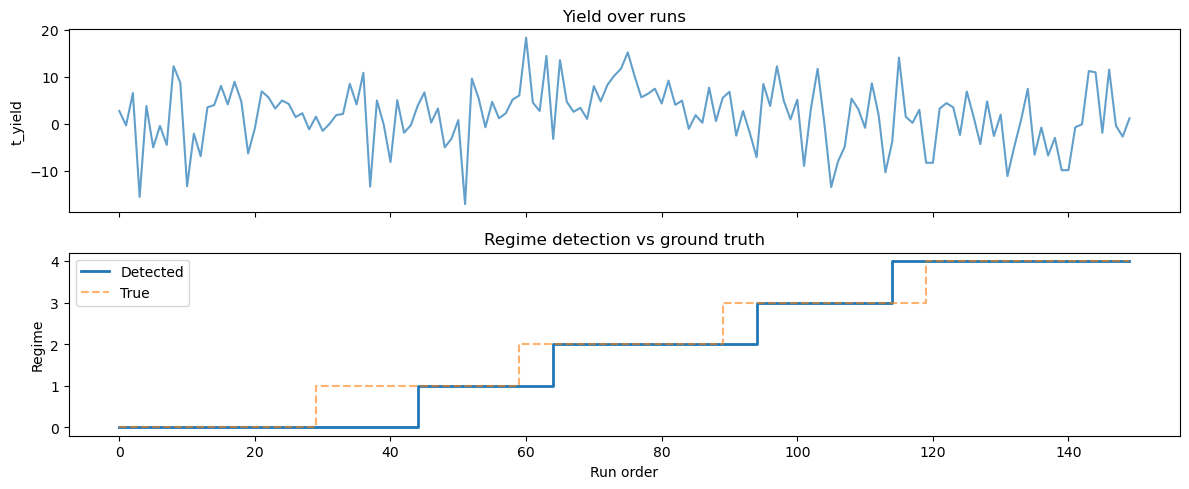

In [9]:
# Step 2: Detect regimes (uses numeric detection features only)
regime_labels, diagnostics = detect_regimes(completed, detection_feature_cols, target_col="t_yield")

print(f"Detected regime labels: {np.unique(regime_labels, return_counts=True)}")
print(f"True regimes:           {np.unique(completed['true_regime'].values, return_counts=True)}")

# Visualise
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(completed['t_yield'].values, alpha=0.7)
axes[0].set_ylabel('t_yield')
axes[0].set_title('Yield over runs')

axes[1].step(range(len(regime_labels)), regime_labels, label='Detected', linewidth=2)
axes[1].step(range(len(regime_labels)), completed['true_regime'].values, label='True', alpha=0.6, linestyle='--')
axes[1].set_ylabel('Regime')
axes[1].set_xlabel('Run order')
axes[1].legend()
axes[1].set_title('Regime detection vs ground truth')
plt.tight_layout()
plt.show()

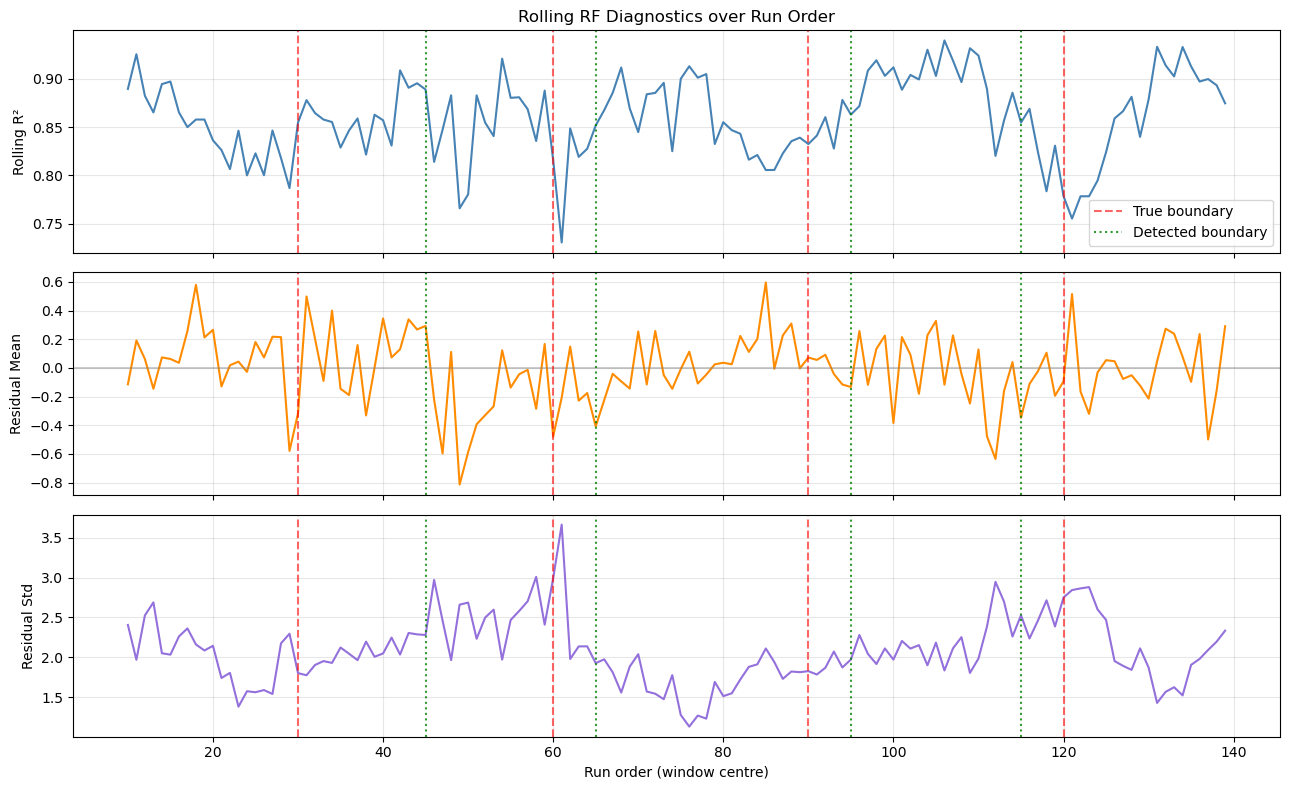

Detected boundaries at runs: [45, 65, 95, 115]
True boundaries at runs: [30, 60, 90, 120]


In [10]:
# Diagnostic visualisation: rolling R², residual mean, and residual std over run order
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

true_cps = TRUE_CHANGEPOINTS  # derived from data in cell 3

# --- R² ---
ax = axes[0]
ax.plot(diagnostics["run_center"], diagnostics["rolling_r2"], color="steelblue", linewidth=1.5)
for cp in true_cps:
    ax.axvline(cp, color="red", linestyle="--", alpha=0.6, label="True boundary" if cp == true_cps[0] else None)
# Mark detected boundaries
boundaries = []
prev = regime_labels[0]
for i in range(1, len(regime_labels)):
    if regime_labels[i] != prev:
        boundaries.append(i)
        prev = regime_labels[i]
for i, bp in enumerate(boundaries):
    ax.axvline(bp, color="green", linestyle=":", alpha=0.8, label="Detected boundary" if i == 0 else None)
ax.set_ylabel("Rolling R²")
ax.set_title("Rolling RF Diagnostics over Run Order")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

# --- Residual mean ---
ax = axes[1]
ax.plot(diagnostics["run_center"], diagnostics["residual_mean"], color="darkorange", linewidth=1.5)
ax.axhline(0, color="gray", linestyle="-", alpha=0.4)
for cp in true_cps:
    ax.axvline(cp, color="red", linestyle="--", alpha=0.6)
for bp in boundaries:
    ax.axvline(bp, color="green", linestyle=":", alpha=0.8)
ax.set_ylabel("Residual Mean")
ax.grid(True, alpha=0.3)

# --- Residual std ---
ax = axes[2]
ax.plot(diagnostics["run_center"], diagnostics["residual_std"], color="mediumpurple", linewidth=1.5)
for cp in true_cps:
    ax.axvline(cp, color="red", linestyle="--", alpha=0.6)
for bp in boundaries:
    ax.axvline(bp, color="green", linestyle=":", alpha=0.8)
ax.set_ylabel("Residual Std")
ax.set_xlabel("Run order (window centre)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Detected boundaries at runs: {boundaries}")
print(f"True boundaries at runs: {true_cps}")

In [11]:
# Step 3: Identify stable features
X_for_stability = completed[feature_cols]
y_for_stability = completed["t_yield"].values

stable_features, stability_df = stability_selection(
    X_for_stability, y_for_stability,
    regime_labels=regime_labels,
    n_bootstraps=30,
)

print(f"\nStable features ({len(stable_features)}): {stable_features}")
print(f"\nFull stability table:")
display(stability_df.head(15))


Stable features (5): ['f_moderate_linear_1', 'f_strong_linear_2', 'c_context_cat_1', 'f_strong_linear_1', 'f_moderate_linear_0']

Full stability table:


,mean_importance,freq_significant
feature,,
f_moderate_linear_1,0.093236,0.300000
f_strong_linear_2,0.082292,0.266667
c_context_cat_1,0.080763,0.300000
f_strong_linear_1,0.075623,0.266667
f_moderate_linear_0,0.066984,0.133333
f_noise_0,0.066364,0.166667
f_strong_linear_0,0.054634,0.133333
f_noise_4,0.047952,0.133333
f_noise_1,0.043226,0.000000


In [12]:
# Step 4: Fit all three surrogate models on current data
current_regime = regime_labels[-1]
regime_size = (regime_labels == current_regime).sum()
regime_data = completed.loc[regime_labels == current_regime]
print(f"Current regime: {current_regime} ({regime_size} runs)")

# 4a. Local-only surrogate (current regime data)
model_local, local_features = fit_local_surrogate(
    completed, regime_labels, feature_cols, target_col="t_yield",
)
print(f"\nLocal surrogate: trained on {regime_size} runs, {len(local_features)} features")

# 4b. Global-naive surrogate (all data, single pool)
global_labels = np.zeros(len(completed), dtype=int)
model_global, global_features = fit_local_surrogate(
    completed, global_labels, feature_cols, target_col="t_yield",
)
print(f"Global-naive surrogate: trained on {len(completed)} runs, {len(global_features)} features")

# 4c. Global-residual surrogate (global backbone + per-regime residuals)
gr_bundle = fit_global_residual_surrogate(
    completed, regime_labels, feature_cols, target_col="t_yield",
)
print(f"Global-residual surrogate: backbone on {len(completed)} runs, "
      f"residual models for regimes {list(gr_bundle['regime_preds'](completed[feature_cols][:1]).keys())}")


Current regime: 4 (35 runs)

Local surrogate: trained on 35 runs, 23 features
Global-naive surrogate: trained on 150 runs, 23 features
Global-residual surrogate: backbone on 150 runs, residual models for regimes [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [13]:
# Step 5: Generate candidates and score with all three models
bounds = {c: (-1.0, 1.0) for c in decision_cols}
candidates = generate_candidates(bounds, n_candidates=500, seed=42)

# Score with each model
scores_local = score_candidates(candidates, model_local, local_features, regime_data)
scores_global = score_candidates(candidates, model_global, global_features, completed)

# For global_residual, align candidates to full feature frame then predict
aligned_gr = pd.DataFrame(index=candidates.index)
for col in feature_cols:
    if col in candidates.columns:
        aligned_gr[col] = candidates[col].values
    elif col in regime_data.columns:
        if regime_data[col].dtype.kind in ("f", "i"):
            aligned_gr[col] = float(regime_data[col].median())
        else:
            mode_val = regime_data[col].mode()
            aligned_gr[col] = mode_val.iloc[0] if len(mode_val) > 0 else "missing"
    else:
        if col.startswith("c_context_cat"):
            aligned_gr[col] = "missing"
        else:
            aligned_gr[col] = 0.0
scores_gr = gr_bundle["predict"](aligned_gr)

print(f"Local      scores — min: {scores_local.min():.2f}, max: {scores_local.max():.2f}, mean: {scores_local.mean():.2f}")
print(f"Global     scores — min: {scores_global.min():.2f}, max: {scores_global.max():.2f}, mean: {scores_global.mean():.2f}")
print(f"Global-Res scores — min: {scores_gr.min():.2f}, max: {scores_gr.max():.2f}, mean: {scores_gr.mean():.2f}")


Local      scores — min: -0.60, max: 1.74, mean: 0.59
Global     scores — min: 0.01, max: 1.55, mean: 0.54
Global-Res scores — min: -0.45, max: 2.76, mean: 1.24


In [14]:
# Step 6: Select a batch from each model
batch_local = select_batch(candidates, scores_local, batch_size=5, n_explore=1, seed=42)
batch_global = select_batch(candidates, scores_global, batch_size=5, n_explore=1, seed=42)
batch_gr = select_batch(candidates, scores_gr, batch_size=5, n_explore=1, seed=42)

print("Local-Only Recommended Batch:")
display(batch_local)
print("\nGlobal-Naive Recommended Batch:")
display(batch_global)
print("\nGlobal-Residual Recommended Batch:")
display(batch_gr)


Local-Only Recommended Batch:


,d_decision_0,d_decision_1,d_decision_2,predicted_yield,run_type
0,0.857207,-0.764828,-0.957208,1.744385,exploit
1,0.942782,-0.670212,-0.856388,1.723827,exploit
2,0.899554,0.094462,-0.744242,1.690794,exploit
3,0.959963,-0.308753,-0.932125,1.690794,exploit
4,0.357676,0.398613,-0.574364,1.194133,explore



Global-Naive Recommended Batch:


,d_decision_0,d_decision_1,d_decision_2,predicted_yield,run_type
0,0.748538,-0.838958,0.876797,1.551521,exploit
1,0.891748,-0.787875,0.982757,1.531166,exploit
2,0.879055,-0.940196,0.327386,1.512678,exploit
3,0.946041,-0.918529,0.542664,1.478363,exploit
4,0.357676,0.398613,-0.574364,0.280115,explore



Global-Residual Recommended Batch:


,d_decision_0,d_decision_1,d_decision_2,predicted_yield,run_type
0,0.857207,-0.764828,-0.957208,2.761007,exploit
1,0.728557,-0.796528,-0.502458,2.616124,exploit
2,0.836447,-0.975719,-0.660399,2.586087,exploit
3,0.651480,-0.921903,-0.120908,2.560400,exploit
4,0.231909,0.740166,-0.645929,1.750817,explore


---
## 4. Full Adaptive Loop (Simulation)

Now run the full iterative loop: recommend → execute (oracle) → accumulate → repeat.

**Four-way comparison:**
- **Local-Only** (`local_only`) — detect regimes, fit surrogate on current regime only
- **Global-Naive** (`global_naive`) — same pipeline but trained on ALL data (no regime segmentation)
- **Global-Residual** (`global_residual`) — global backbone + per-regime residual models, using detected regimes
- **Random** — uniform random decision variables (floor baseline)

All three adaptive methods use the same expanded feature set (including categorical context).
The comparison isolates the value of regime-aware training scope.


In [15]:
def run_adaptive_loop(
    initial_df: pd.DataFrame,
    oracle: SyntheticOracle,
    regime_schedule: list[tuple[int, int]],
    n_iterations: int = 15,
    batch_size: int = 5,
    n_explore: int = 1,
    method: str = "local_only",  # "local_only", "global_naive", "global_residual", or "random"
    seed: int = 42,
) -> dict:
    """Run the full adaptive DoE loop.

    Methods
    -------
    local_only       : Detect regimes, fit surrogate on current regime only.
    global_naive     : No regime detection, surrogate on ALL data.
    global_residual  : Detect regimes, global backbone + per-regime residuals.
    random           : Uniform random decision variables.
    """
    df = initial_df.copy()
    run_counter = len(df)
    decision_cols = [c for c in df.columns if c.startswith("d_")]
    det_feature_cols = get_detection_feature_cols(df)
    surr_feature_cols = get_surrogate_feature_cols(df, "expanded")
    bounds = {c: (-1.0, 1.0) for c in decision_cols}

    history = {"iteration": [], "batch_best": [], "cumulative_best": [], "n_runs": []}

    for it in range(n_iterations):
        # Current regime from schedule
        current_regime = 0
        for threshold, regime in regime_schedule:
            if run_counter >= threshold:
                current_regime = regime

        if method == "local_only":
            # Complete → detect regimes (numeric) → surrogate on current regime (expanded)
            completed = complete_data(df)
            regime_labels, _ = detect_regimes(completed, det_feature_cols)
            model, model_features = fit_local_surrogate(
                completed, regime_labels, surr_feature_cols, seed=seed + it,
            )
            candidates = generate_candidates(bounds, n_candidates=500, seed=seed + it)
            regime_data = completed.loc[regime_labels == regime_labels[-1]]
            scores = score_candidates(candidates, model, model_features, regime_data)
            batch = select_batch(candidates, scores, batch_size, n_explore, seed=seed + it)
            rec_df = batch[decision_cols]

        elif method == "global_naive":
            # Complete → NO regime detection → surrogate on ALL data (expanded)
            completed = complete_data(df)
            global_labels = np.zeros(len(completed), dtype=int)
            model, model_features = fit_local_surrogate(
                completed, global_labels, surr_feature_cols, seed=seed + it,
            )
            candidates = generate_candidates(bounds, n_candidates=500, seed=seed + it)
            scores = score_candidates(candidates, model, model_features, completed)
            batch = select_batch(candidates, scores, batch_size, n_explore, seed=seed + it)
            rec_df = batch[decision_cols]

        elif method == "global_residual":
            # Complete → detect regimes → global backbone + per-regime residuals
            completed = complete_data(df)
            regime_labels, _ = detect_regimes(completed, det_feature_cols)
            gr_bundle = fit_global_residual_surrogate(
                completed, regime_labels, surr_feature_cols, seed=seed + it,
            )
            candidates = generate_candidates(bounds, n_candidates=500, seed=seed + it)
            regime_data = completed.loc[regime_labels == regime_labels[-1]]
            # Align candidates to full feature frame
            aligned = pd.DataFrame(index=candidates.index)
            for col in surr_feature_cols:
                if col in candidates.columns:
                    aligned[col] = candidates[col].values
                elif col in regime_data.columns:
                    if regime_data[col].dtype.kind in ("f", "i"):
                        aligned[col] = float(regime_data[col].median())
                    else:
                        mode_val = regime_data[col].mode()
                        aligned[col] = mode_val.iloc[0] if len(mode_val) > 0 else "missing"
                else:
                    if col.startswith("c_context_cat"):
                        aligned[col] = "missing"
                    else:
                        aligned[col] = 0.0
            scores = gr_bundle["predict"](aligned)
            batch = select_batch(candidates, scores, batch_size, n_explore, seed=seed + it)
            rec_df = batch[decision_cols]

        else:
            # Random baseline
            rng = np.random.default_rng(seed + it)
            rec_df = pd.DataFrame({
                c: rng.uniform(*bounds[c], size=batch_size) for c in decision_cols
            })

        # Execute via oracle
        new_runs = oracle.evaluate(rec_df, regime=current_regime, run_order_start=run_counter)
        run_counter += len(new_runs)
        df = pd.concat([df, new_runs], ignore_index=True)

        batch_best = float(new_runs["t_yield"].max())
        cum_best = float(df["t_yield"].max())

        history["iteration"].append(it)
        history["batch_best"].append(batch_best)
        history["cumulative_best"].append(cum_best)
        history["n_runs"].append(run_counter)

        if (it + 1) % 5 == 0:
            print(f"  [{method}] iter {it+1}/{n_iterations} — batch_best={batch_best:.2f}, cum_best={cum_best:.2f}")

    return history

print("Adaptive loop defined (methods: local_only, global_naive, global_residual, random).")


Adaptive loop defined (methods: local_only, global_naive, global_residual, random).


In [16]:
# Run all four methods
schedule = REGIME_SCHEDULE  # derived from data in cell 3
initial = observed_df.copy()

print(f"Using schedule: {schedule}")
print(f"[SANITY] Oracle noise override: None")
print(f"[SANITY] Hard mode uses regime-specific noise schedule")

print(f"\nRunning local-only (regime-aware)...")
oracle_lo = SyntheticOracle(seed=42)
lo_history = run_adaptive_loop(initial, oracle_lo, schedule, n_iterations=15, method="local_only", seed=42)

print("\nRunning global-naive (no regime segmentation)...")
oracle_gn = SyntheticOracle(seed=42)
gn_history = run_adaptive_loop(initial, oracle_gn, schedule, n_iterations=15, method="global_naive", seed=42)

print("\nRunning global-residual (backbone + residuals)...")
oracle_gr = SyntheticOracle(seed=42)
gr_history = run_adaptive_loop(initial, oracle_gr, schedule, n_iterations=15, method="global_residual", seed=42)

print("\nRunning random baseline...")
oracle_rand = SyntheticOracle(seed=42)
rand_history = run_adaptive_loop(initial, oracle_rand, schedule, n_iterations=15, method="random", seed=42)


Using schedule: [(0, 0), (30, 1), (60, 2), (90, 3), (120, 4)]
[SANITY] Oracle noise override: None
[SANITY] Hard mode uses regime-specific noise schedule

Running local-only (regime-aware)...
  [local_only] iter 5/15 — batch_best=18.13, cum_best=18.29
  [local_only] iter 10/15 — batch_best=15.02, cum_best=18.29
  [local_only] iter 15/15 — batch_best=10.03, cum_best=18.29

Running global-naive (no regime segmentation)...
  [global_naive] iter 5/15 — batch_best=16.23, cum_best=18.29
  [global_naive] iter 10/15 — batch_best=14.97, cum_best=18.29
  [global_naive] iter 15/15 — batch_best=9.48, cum_best=18.29

Running global-residual (backbone + residuals)...
  [global_residual] iter 5/15 — batch_best=17.03, cum_best=18.29
  [global_residual] iter 10/15 — batch_best=14.89, cum_best=18.29
  [global_residual] iter 15/15 — batch_best=8.56, cum_best=18.29

Running random baseline...
  [random] iter 5/15 — batch_best=7.39, cum_best=18.29
  [random] iter 10/15 — batch_best=5.99, cum_best=18.29
  [

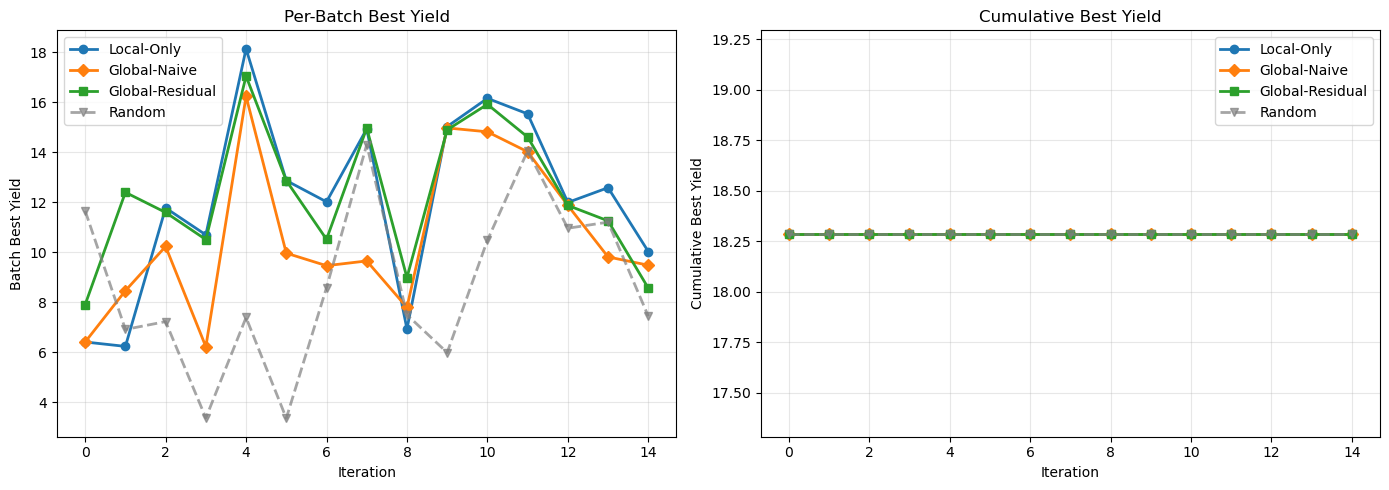


Final cumulative best — Local-Only: 18.29, Global-Naive: 18.29, Global-Residual: 18.29, Random: 18.29
Mean batch best      — Local-Only: 12.08, Global-Naive: 10.62, Global-Residual: 12.25, Random: 8.69


In [17]:
# Plot four-way comparison
_methods = [
    ("Local-Only",       lo_history,   "tab:blue",   "o-"),
    ("Global-Naive",     gn_history,   "tab:orange",  "D-"),
    ("Global-Residual",  gr_history,   "tab:green",  "s-"),
    ("Random",           rand_history, "tab:gray",   "v--"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for label, hist, color, fmt in _methods:
    ax.plot(hist["iteration"], hist["batch_best"], fmt, label=label, linewidth=2, color=color,
            alpha=0.7 if label == "Random" else 1.0)
ax.set_xlabel("Iteration")
ax.set_ylabel("Batch Best Yield")
ax.set_title("Per-Batch Best Yield")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for label, hist, color, fmt in _methods:
    ax.plot(hist["iteration"], hist["cumulative_best"], fmt, label=label, linewidth=2, color=color,
            alpha=0.7 if label == "Random" else 1.0)
ax.set_xlabel("Iteration")
ax.set_ylabel("Cumulative Best Yield")
ax.set_title("Cumulative Best Yield")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal cumulative best — Local-Only: {lo_history['cumulative_best'][-1]:.2f}, "
      f"Global-Naive: {gn_history['cumulative_best'][-1]:.2f}, "
      f"Global-Residual: {gr_history['cumulative_best'][-1]:.2f}, "
      f"Random: {rand_history['cumulative_best'][-1]:.2f}")
print(f"Mean batch best      — Local-Only: {np.mean(lo_history['batch_best']):.2f}, "
      f"Global-Naive: {np.mean(gn_history['batch_best']):.2f}, "
      f"Global-Residual: {np.mean(gr_history['batch_best']):.2f}, "
      f"Random: {np.mean(rand_history['batch_best']):.2f}")


---
## 5. Multi-Seed Benchmark

Run multiple seeds to get a statistically meaningful four-way comparison:
**Local-Only** vs **Global-Naive** vs **Global-Residual** vs **Random**.


In [18]:
from scipy import stats as sp_stats

n_seeds = 10
n_iters = 15

METHOD_KEYS = ["local_only", "global_naive", "global_residual", "random"]
METHOD_LABELS = {"local_only": "Local-Only", "global_naive": "Global-Naive",
                 "global_residual": "Global-Residual", "random": "Random"}

# Storage
finals = {m: [] for m in METHOD_KEYS}
batch_means = {m: [] for m in METHOD_KEYS}
batch_traces = {m: np.zeros((n_seeds, n_iters)) for m in METHOD_KEYS}

for s in range(n_seeds):
    seed = 42 + s
    for m in METHOD_KEYS:
        oracle = SyntheticOracle(seed=seed)
        h = run_adaptive_loop(initial, oracle, schedule, n_iterations=n_iters, method=m, seed=seed)
        finals[m].append(h["cumulative_best"][-1])
        batch_means[m].append(np.mean(h["batch_best"]))
        batch_traces[m][s] = h["batch_best"]

    print(f"  seed {seed}: " + ", ".join(
        f"{METHOD_LABELS[m]}={finals[m][-1]:.2f}" for m in METHOD_KEYS))

# --- Summary statistics ---
print(f"\n{'='*70}")
print(f"Results ({n_seeds} seeds)")
print(f"{'='*70}")

print(f"\n--- Final Cumulative Best Yield ---")
for m in METHOD_KEYS:
    print(f"  {METHOD_LABELS[m]:20s}: {np.mean(finals[m]):.2f} +/- {np.std(finals[m]):.2f}")

# Pairwise paired t-tests
comparisons = [
    ("local_only", "global_naive"),
    ("local_only", "global_residual"),
    ("local_only", "random"),
    ("global_naive", "global_residual"),
    ("global_naive", "random"),
    ("global_residual", "random"),
]

print(f"\n--- Pairwise Paired t-tests (Final Cumulative Best) ---")
for ma, mb in comparisons:
    t_val, p_val = sp_stats.ttest_rel(finals[ma], finals[mb])
    sig = " <-- significant" if p_val < 0.05 else " (not significant)"
    print(f"  {METHOD_LABELS[ma]} vs {METHOD_LABELS[mb]}:  t={t_val:.3f}, p={p_val:.4f}{sig}")

print(f"\n--- Mean Batch Best Yield ---")
for m in METHOD_KEYS:
    print(f"  {METHOD_LABELS[m]:20s}: {np.mean(batch_means[m]):.2f} +/- {np.std(batch_means[m]):.2f}")

print(f"\n--- Pairwise Paired t-tests (Mean Batch Best) ---")
for ma, mb in comparisons:
    t_val, p_val = sp_stats.ttest_rel(batch_means[ma], batch_means[mb])
    sig = " <-- significant" if p_val < 0.05 else " (not significant)"
    print(f"  {METHOD_LABELS[ma]} vs {METHOD_LABELS[mb]}:  t={t_val:.3f}, p={p_val:.4f}{sig}")


  [local_only] iter 5/15 — batch_best=18.13, cum_best=18.29
  [local_only] iter 10/15 — batch_best=15.02, cum_best=18.29
  [local_only] iter 15/15 — batch_best=10.03, cum_best=18.29
  [global_naive] iter 5/15 — batch_best=16.23, cum_best=18.29
  [global_naive] iter 10/15 — batch_best=14.97, cum_best=18.29
  [global_naive] iter 15/15 — batch_best=9.48, cum_best=18.29
  [global_residual] iter 5/15 — batch_best=17.03, cum_best=18.29
  [global_residual] iter 10/15 — batch_best=14.89, cum_best=18.29
  [global_residual] iter 15/15 — batch_best=8.56, cum_best=18.29
  [random] iter 5/15 — batch_best=7.39, cum_best=18.29
  [random] iter 10/15 — batch_best=5.99, cum_best=18.29
  [random] iter 15/15 — batch_best=7.44, cum_best=18.29
  seed 42: Local-Only=18.29, Global-Naive=18.29, Global-Residual=18.29, Random=18.29
  [local_only] iter 5/15 — batch_best=12.98, cum_best=18.29
  [local_only] iter 10/15 — batch_best=13.17, cum_best=18.29
  [local_only] iter 15/15 — batch_best=15.38, cum_best=18.29
 

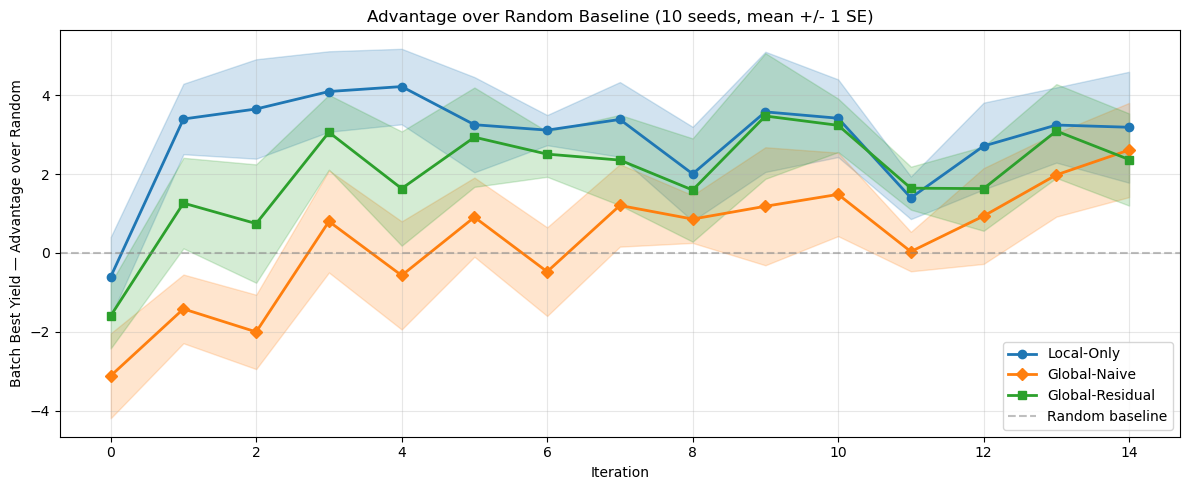

Mean advantage over random (across all iterations):
  Local-Only          : +2.94
  Global-Naive        : +0.30
  Global-Residual     : +2.00

  Local-Only vs Global-Naive:     +2.64
  Local-Only vs Global-Residual:  +0.94


In [19]:
# Advantage over random: how much better is each adaptive method than random, per iteration?
iterations = np.arange(n_iters)

_adaptive_methods = ["local_only", "global_naive", "global_residual"]
_colors = {"local_only": "tab:blue", "global_naive": "tab:orange", "global_residual": "tab:green"}
_markers = {"local_only": "o-", "global_naive": "D-", "global_residual": "s-"}

fig, ax = plt.subplots(figsize=(12, 5))

for m in _adaptive_methods:
    delta = batch_traces[m] - batch_traces["random"]  # (n_seeds, n_iters)
    delta_mean = delta.mean(axis=0)
    delta_se = delta.std(axis=0) / np.sqrt(n_seeds)
    ax.plot(iterations, delta_mean, _markers[m], label=METHOD_LABELS[m], linewidth=2, color=_colors[m])
    ax.fill_between(iterations, delta_mean - delta_se, delta_mean + delta_se,
                    alpha=0.2, color=_colors[m])

ax.axhline(0, color="gray", linestyle="--", alpha=0.5, label="Random baseline")
ax.set_xlabel("Iteration")
ax.set_ylabel("Batch Best Yield — Advantage over Random")
ax.set_title(f"Advantage over Random Baseline ({n_seeds} seeds, mean +/- 1 SE)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary stats
print(f"Mean advantage over random (across all iterations):")
for m in _adaptive_methods:
    delta_mean = (batch_traces[m] - batch_traces["random"]).mean(axis=0)
    print(f"  {METHOD_LABELS[m]:20s}: {delta_mean.mean():+.2f}")
print(f"\n  Local-Only vs Global-Naive:     {((batch_traces['local_only'] - batch_traces['random']).mean(axis=0) - (batch_traces['global_naive'] - batch_traces['random']).mean(axis=0)).mean():+.2f}")
print(f"  Local-Only vs Global-Residual:  {((batch_traces['local_only'] - batch_traces['random']).mean(axis=0) - (batch_traces['global_residual'] - batch_traces['random']).mean(axis=0)).mean():+.2f}")


---
## Summary

This notebook implements the complete regime-aware adaptive DoE with a four-way comparison:

1. **Regime detection**: rolling RF diagnostics → PELT changepoint (L2, 6 channels, window=20, penalty=8.0) → segment labels
2. **Stable features**: noise-referenced bootstrap stability selection
3. **Adaptive recommendation**: CatBoost surrogate (with native categorical handling) → LHS candidates → predict + rank → exploit/explore batch

**Four-way benchmark**: Local-Only (current regime) vs Global-Naive (all data) vs Global-Residual (backbone + residuals) vs Random.

This isolates the value of regime-aware training scope from the value of cross-regime memory, while controlling for feature scope (all methods use expanded features including categorical context).

All dependencies are standard scientific Python (`catboost`, `ruptures`, `scipy`, `sklearn`, `numpy`, `pandas`).
